### ReAct Agent Architecture

#### Aim
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

C:\Users\saran_s\AppData\Local\Temp\ipykernel_13180\1871147362.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun


In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [6]:
def multiply(a:int, b:int)-> int:
    """ multiply a and b.
    
    Args:
        a: first int
        b: second int

    """
    return a * b

def add(a:int, b:int)->int:
    """ add a and b.
    
    args:
        a : first int
        b: second int
    
    """
    return a + b

def divide(a:int, b:int)-> int:
    """ divide a and b 
    
    Args:
        a: first int
        b: second int

    """
    return a / b 

tools = [arxiv, wiki, add, multiply, divide]

In [7]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\saran_s\AppData\Local\Temp\ipykernel_13180\735679136.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [8]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'March 2025 - The Artificial Intelligence Revolution',
  'url': 'https://choreoadvisors.com/market-perspectives/march-2025-the-artificial-intelligence-revolution',
  'content': 'There are plenty of signs that AI is beginning to have a material effect on the world. One of the early signals may be the valuation of AI-related private companies such as OpenAI. Investors are willing to pay up for what they believe could be a potential leader in the field. The ChatGPT maker’s most recent funding round in the private markets valued the company at $300 billion. At current markets as of 3/3/25, this would place it as the 27th largest company in the S&P 500, a staggering valuation for a private entity. [...] There are risks abounding in the technology itself and the rapidly evolving investment landscape surrounding AI. Often with new technology, the initial spend is high as an arms race of sorts ensues. Also of note, the first companies and technology paths are often not the ultimate 

In [9]:
tools = [arxiv, wiki, add, multiply, divide, tavily]

In [10]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3.6-27b")
llm_with_tools = llm.bind_tools(tools)

d:\OneDrive - Maarga Systems Private Limited\Documents\Agentic-AI-BridgeCourse\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
from langchain_core.messages import HumanMessage, AIMessage

llm_with_tools.invoke([HumanMessage(content="what is ai, give me recent news about ai")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Thinking Process:\n\n1.  **Understand the User\'s Request**: The user is asking for two things:\n    *   A definition/explanation of "AI" (Artificial Intelligence).\n    *   Recent news about AI.\n\n2.  **Part 1: Define AI**:\n    *   I already know what AI is. It\'s the simulation of human intelligence processes by machines, especially computer systems. These processes include learning (acquiring information and rules for using it), reasoning (using rules to reach approximate or definite conclusions), and self-correction.\n    *   I can provide a concise definition without needing a tool, but checking Wikipedia might provide a structured overview or specific subfields if needed. However, a general knowledge answer is sufficient here.\n\n3.  **Part 2: Recent News about AI**:\n    *   I need to find *recent* news. My internal knowledge cutoff might be outdated for "recent" (e.g., specific breakthroughs from last week).\n    

In [12]:
llm_with_tools.invoke([HumanMessage(content="what is ai, give me recent news about ai")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent news about artificial intelligence'},
  'id': '8x91yf5mt',
  'type': 'tool_call'}]

In [13]:
from typing_extensions import TypedDict
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


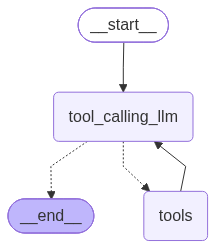

In [14]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_llm(state:State):
    return {"messages":llm_with_tools.invoke(state["messages"])}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  add (yydyaky56)
 Call ID: yydyaky56
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: add

10
================================== Ai Message ==================================
Tool Calls:
  multiply (728j8s85a)
 Call ID: 728j8s85a
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: multiply

100
================================== Ai Message ==================================

March 3rd, 2025, is in the future, so I cannot provide news for that date.

However, the result of your calculation is:
5 + 5 = 10
10 * 10 = **100**

If you meant a different date, please let me know!


In [19]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (v7br3j4dq)
 Call ID: v7br3j4dq
  Args:
    query: top 10 AI news March 3 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Top 10 AI Developments in the Past Week [Week 1 - March 2025 ]", "url": "https://datahubanalytics.com/top-10-ai-developments-in-the-past-week-week-1-march-2025", "content": "Datahub Analytics\n\n العربية (Arabic)\n English\n\nai-news-dha\n\n## Top 10 AI Developments in the Past Week [Week 1 – March 2025 ]\n\nAnalytics / Artificial Intelligence / Business / Data Analytics / Data Security / Infrastructure\n\n# Top 10 AI Developments in the Past Week [Week 1 – March 2025 ]\n\n Waseem AL Rousan\n

### Agent Memory
#### Aim
Lets introduce Agent With Memory

In [21]:
messages = graph.invoke({"messages":[HumanMessage(content="what is 5 plus 8")]})
for i in messages["messages"]:
    i.pretty_print()
    

================================ Human Message =================================

what is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (4e7cpv6er)
 Call ID: 4e7cpv6er
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

5 plus 8 is 13.


In [24]:
messages = graph.invoke({"messages":[HumanMessage(content="divide that by 5?")]})

for i in messages["messages"]:
    i.pretty_print()
    
    

================================ Human Message =================================

divide that by 5?
================================== Ai Message ==================================

Could you please tell me which number you'd like me to divide by 5? I don't have the previous context to know what "that" refers to.


#### MemorySaver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

In [25]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000268C3D634A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000268C18750A0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [26]:
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000268C3D634A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000268C18750A0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'arxiv', 'description': 'A wrap

In [29]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

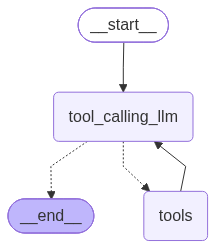

In [30]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph_memory = builder.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [32]:
config = {"configurable": {"thread_id":"chat1"}}

message = graph.invoke({"messages":[HumanMessage(content="two plus two please?")]}, config=config)

for i in message["messages"]:
    i.pretty_print()

================================ Human Message =================================

two plus two please?
================================== Ai Message ==================================

Two plus two equals **4**.


In [34]:
message = graph.invoke({"messages":[HumanMessage(content="can you add that with two plus two please?")]}, config=config)
for i in message["messages"]:
    i.pretty_print()

================================ Human Message =================================

can you add that with two plus two please?
================================== Ai Message ==================================
Tool Calls:
  add (fc_448e268d-1978-43bc-b0c1-6285b307d8d4)
 Call ID: fc_448e268d-1978-43bc-b0c1-6285b307d8d4
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
================================== Ai Message ==================================

Sure thing! 2 + 2 = 4.


In [35]:
messages = [HumanMessage(content="then multiplty that number by 2")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

then multiplty that number by 2
================================== Ai Message ==================================

I’m not sure which number you’d like to double—could you let me know the value you’d like multiplied by 2?
